# Étape 2

Étape 2 : Étape de nettoyage Dans cette étape, on s’intéresse à implémenter les correctifs soulignés dans l’étape 1. De ce fait, il serait important de considérer les opérations suivantes : 

* Imputing: évaluer les colonnes avec des valeurs manquantes. Par exemple, voir les colonnes: 
* title, revol_util et pub_rec_bankruptcies Une stratégie à employer: Supprimer la colonne ayant plus de 1 à 2% de valeurs manquantes Supprimer les lignes ayant des valeurs NaN  

* Convertir les colonnes catégorielles en numériques. Faire attention ici aux valeurs ordinales et nominales (dummy var).  

* Suppression de colonnes non adéquates pour la prédiction  

* Suppression des colonnes qui ne seront intéressantes que pour prédire le statut de paiement du prêt. Les colonnes dont les valeurs seront obtenues après le prêt ne doivent pas être considérées. Par exemple, évaluer si les colonnes suivantes sont à supprimer:  

	* zip_code  
	* out_prncp  
	* out_prncp_inv  
	* total_pymnt  
	* total_pymnt_inv  
	* total_rec_prncp  
	* total_rec_int  
	* total_rec_late_fee  
	* recoveries  
	* collection_recovery_fee  
	* last_pymnt_d  
	* last_pymnt_amnt  

Vérifier si la colonne cible est dans un format adéquat pour le modèle.  

Correction/Standardisation/Normalisation de données  

In [46]:

import pandas as pd 
import numpy as np
from utils.utils import distributional_summary, degree_completeness, plot_distributions, plot_boxplots
import matplotlib.pyplot as plt 
from typing import Dict, List, Callable, Any, Tuple
from sklearn.preprocessing import StandardScaler


df_data = pd.read_csv('data/lending_club_loans.csv') 
labels = pd.read_excel('data/lending_club_data_dic.xlsx') 
labels.index = labels['LoanStatNew']
labels = labels.drop(columns=['LoanStatNew'])
labels = labels.loc[df_data.columns] # ! limits labels to our variables of interests


def convert_percentage(serie:pd.Series):
  return [ float(str(v).replace('%', '')) for v in serie.values]

def convert_date(serie:pd.Series): 
  return pd.to_datetime(serie, format='%b-%y') 

def delta_month(d1:pd.Series, d2:pd.Series):
	return ( (d1.dt.year - d2.dt.year) * 12 + (d1.dt.month - d2.dt.month) ).astype('Int64')

def mean_category(serie:pd.Series, encoding:dict) -> str:
	reversed = { v:k for k,v in encoding.items() } # ! reverse to encoding to get conversion FROM cat -> num instead of num -> cat 
	mean = round(pd.Series([ reversed.get(v, np.nan) for v in serie.values ]).mean(), 0) 
	return encoding[mean] 



# ! Identify varnames groups for particular treatments later 
summary = distributional_summary(df_data) 
varname_id = ['id', 'member_id'] 
varname_cardinality_1 = summary.loc[:, summary.loc['cardinality'] == 1].columns # ! to document. 
varname_date = ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line', 'issue_d'] 
varname_percentage = ['int_rate', 'revol_util'] 


## Encodage des variables categoriques

In [47]:

# ! Infer encoding values for categorical values 
df = df_data.copy() 
cat_var = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'addr_state'] 

encodings = {
  'emp_length':{
    0: '< 1 year',
    1: '1 year',
    2: '2 years',
    3: '3 years',
    4: '4 years',
    5: '5 years',
    6: '6 years',
    7: '7 years',
    8: '8 years',
    9: '9 years',
    10: '10+ years'}
}

for c in cat_var:
	encodings[c] = { i:v for i,v in enumerate(sorted(df[c].unique()))}

varname_cat = list(encodings.keys())

### Regle de transformations. 
* Correction: il faudra regrouper les valeurs possibles de 'loan_status' en 2 categorie; 1:'Fully Paid', 0:'Not-fully paid' 
* Corrections: Retirer ces 7 colonnes de notre dataset.
* Correction: Convertir au format "float".
* Corrections: Convertir au format "datetime".
* Corrections: Certaines imputations sont possibles. Dans d'autres cas, les observations avec valeurs manquantes devront etre retire. (Detail des corrections imputations et nettoyage dans la seconde partie). 
* Corrections: Apres une premiere imputations recalculer la completude et reevaluer. 

Variables a retirer 
  'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', # ! There
  'last_pymnt_d', 'last_pymnt_amnt'
] 

In [48]:

# ? Template for transformation function. Helps intellisense and structures
type TransformerFunc = Callable[[pd.DataFrame, str], pd.Series] 

transform_mapper:Dict[str, Tuple[TransformerFunc, str]] = { 
	# ! convert string percentage -> numerical percentage 
  'int_rate': (lambda df,c: convert_percentage(df[c]), None), 
  'revol_util' : (lambda df,c: convert_percentage(df[c]), None), 
  
  # ! convert string date -> datetime values 
  'last_pymnt_d':	(lambda df,c: convert_date(df[c]), None), 
  'last_credit_pull_d': (lambda df,c: convert_date(df[c]), None), 
  'earliest_cr_line': (lambda df,c: convert_date(df[c]), None), 
  'issue_d': (lambda df,c: convert_date(df[c]), None), 
} 

imputations_mapper:Dict[str, Tuple[TransformerFunc, str]] = { 
	# ! Impute mean category from ORDINAL variable "emp_length" instead of using most frequent value. 
  'emp_length': (lambda df,c: mean_category(df[c], encodings[c]), 'emp_length'), 
	
	# ! Impute mean and round to integer value
	'revol_util': (lambda df, c: int(round(df[c].mean(), 0)), 'revol_util'), 
	'pub_rec_bankruptcies': (lambda df, c: int(round(df[c].mean(), 0)), 'pub_rec_bankruptcies'), 
} 

flag_mapper:Dict[str, Tuple[TransformerFunc, str]] = { 
	# ! Flag missing date values instead of imputations 
	'last_pymnt_d': (lambda df, c: pd.notnull(df[c]), 'last_pymnt_d_flag'), # flag null values 
	'last_credit_pull_d': (lambda df, c: pd.notnull(df[c]), 'last_credit_pull_d_flag'), # flag null values 
} 

temporary_variables = ['last_pymnt_d_flag', 'last_credit_pull_d_flag'] 
varname_to_remove = [
  # ! utiliser addr_state
  'zip_code', 
  # ! C'est valeurs semblent etre obtenues apres le pret 
  'last_pymnt_d', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv', 
  'total_pymnt', 'total_pymnt_inv', 'total_rec_late_fee', 
  'recoveries', 'collection_recovery_fee', 'loan_status', 
] 

### Execution des transformations

In [49]:

df_transformed = df_data.copy()


# ! Transformations de notre variables cible. 
# ! If loan_status == 'Fully Paid' then y = 1 else y = 0 
df_transformed['y'] = [ 1 if v == 'Fully Paid' else 0 for v in df_transformed['loan_status'].values ] 


# ! Transformations 
for varname, (func, outvarname) in transform_mapper.items(): 
	outvarname = outvarname or varname 
	df_transformed[outvarname] = func(df_transformed, varname) 

# ! Imputations 
for varname, (func, outvarname) in imputations_mapper.items(): 
	outvarname = outvarname or varname 
	df_transformed[outvarname] = df_transformed[varname].fillna(func(df_transformed, varname)) 

# ? Not necessary if we drop date columns 
# ! Flagging
for varname, (func, outvarname) in flag_mapper.items(): 
	outvarname = outvarname or varname 
	df_transformed[outvarname] = func(df_transformed, varname) 


# ! Drop flagged observations 
varname_flag = ['last_pymnt_d_flag', 'last_credit_pull_d_flag'] #  
to_keep = df_transformed[varname_flag].all(axis=1) 
df_transformed['to_keep'] = to_keep
df_rejected = df_transformed[~to_keep]  # ? Keep rejected observations for documentation purposes 
df_transformed = df_transformed[to_keep] 

# ! Remove temporary variables 
df_transformed = df_transformed.drop(columns=['to_keep', *varname_id, *varname_cardinality_1, *temporary_variables, *varname_to_remove]) 

# ! Ordonnancement des colonnes 
ordered = ['y', *[ c for c in df_transformed.columns if c != 'y']] 
df_transformed = df_transformed[ordered] 
df_transformed 


,y,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_rec_prncp,total_rec_int,last_credit_pull_d,pub_rec_bankruptcies
0,1,5000,5000,4975.0,36 months,10.65,162.87,B,B2,10+ years,...,1,3,0,13648,83.7,9,5000.00,863.16,2017-01-01,0.0
1,0,2500,2500,2500.0,60 months,15.27,59.83,C,C4,< 1 year,...,5,3,0,1687,9.4,4,456.46,435.17,2016-10-01,0.0
2,1,2400,2400,2400.0,36 months,15.96,84.33,C,C5,10+ years,...,2,2,0,2956,98.5,10,2400.00,605.67,2017-01-01,0.0
3,1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,10+ years,...,1,10,0,5598,21.0,37,10000.00,2214.92,2016-04-01,0.0
4,1,3000,3000,3000.0,60 months,12.69,67.79,B,B5,1 year,...,0,15,0,27783,53.9,38,3000.00,1066.91,2017-01-01,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,1,2500,2500,1075.0,36 months,8.07,78.42,A,A4,4 years,...,0,13,0,7274,13.1,40,2500.00,322.97,2010-06-01,0.0
39782,1,8500,8500,875.0,36 months,10.28,275.38,C,C1,3 years,...,1,6,0,8847,26.9,9,8500.00,1413.49,2010-07-01,0.0
39783,1,5000,5000,1325.0,36 months,8.07,156.84,A,A4,< 1 year,...,0,11,0,9698,19.4,20,5000.00,272.16,2007-06-01,0.0
39784,1,5000,5000,650.0,36 months,7.43,155.38,A,A2,< 1 year,...,0,17,0,85607,0.7,26,5000.00,174.20,2007-06-01,0.0


## Standardisation 

In [ ]:
scaler = StandardScaler() 
df_stand = df_transformed.copy()
numeric_cols = df_stand.drop(columns=['y']).select_dtypes(include=[np.number]).columns.tolist() 

scaler.fit(df_stand[numeric_cols])  
df_stand[numeric_cols] = scaler.transform(df_stand[numeric_cols])
  
df_stand

,y,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_rec_prncp,total_rec_int,last_credit_pull_d,pub_rec_bankruptcies
0,1,-0.835725,-0.829216,-0.762454,36 months,-0.368745,-0.775626,B,B2,10+ years,...,0.123126,-1.431291,-0.231848,0.015317,1.230343,-1.149207,-0.682802,-0.538300,2017-01-01,-0.209656
1,0,-1.170711,-1.176817,-1.109310,60 months,0.870749,-1.268960,C,C4,< 1 year,...,3.862849,-1.431291,-0.231848,-0.736833,-1.393301,-1.587777,-1.319394,-0.700850,2016-10-01,-0.209656
2,1,-1.184111,-1.190721,-1.123324,36 months,1.055869,-1.151659,C,C5,10+ years,...,1.058057,-1.658554,-0.231848,-0.657034,1.752954,-1.061493,-1.047086,-0.636095,2017-01-01,-0.209656
3,1,-0.165752,-0.134016,-0.058231,36 months,0.393195,0.069131,C,C1,10+ years,...,0.123126,0.159553,-0.231848,-0.490896,-0.983688,1.306789,0.017744,-0.024904,2016-04-01,-0.209656
4,1,-1.103714,-1.107297,-1.039238,60 months,0.178564,-1.230849,B,B5,1 year,...,-0.811805,1.295870,-0.231848,0.904175,0.178061,1.394503,-0.963021,-0.460917,2017-01-01,-0.209656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,1,-1.170711,-1.176817,-1.309015,36 months,-1.060931,-1.179955,A,A4,4 years,...,-0.811805,0.841343,-0.231848,-0.385503,-1.262649,1.569931,-1.033075,-0.743464,2010-06-01,-0.209656
39782,1,-0.366744,-0.342576,-1.337043,36 months,-0.468012,-0.236952,C,C1,3 years,...,0.123126,-0.749501,-0.231848,-0.286587,-0.775350,-1.149207,-0.192420,-0.329286,2010-07-01,-0.209656
39783,1,-0.835725,-0.829216,-1.273979,36 months,-1.060931,-0.804497,A,A4,< 1 year,...,-0.811805,0.386816,-0.231848,-0.233073,-1.040186,-0.184351,-0.682802,-0.762761,2007-06-01,-0.209656
39784,1,-0.835725,-0.829216,-1.368576,36 months,-1.232636,-0.811487,A,A2,< 1 year,...,-0.811805,1.750397,-0.231848,4.540351,-1.700511,0.341933,-0.682802,-0.799966,2007-06-01,-0.209656


## Dummies
Corrections generales: Toutes les categoriques doivent etre transformer en dummy en preparation a l'analyse. 

In [51]:
print(f"Variables catégorielles à encoder: {varname_cat}")
df_dummies = df_stand.copy()
df_dummies = pd.get_dummies(df_dummies, columns=varname_cat, drop_first=True, dtype=int)
print(f"\nNombre de colonnes après encoding: {df_dummies.shape[1]}")
df_dummies

Variables catégorielles à encoder: ['emp_length', 'term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'addr_state']

Nombre de colonnes après encoding: 127


,y,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
0,1,-0.835725,-0.829216,-0.762454,-0.368745,-0.775626,-0.705587,2011-12-01,2.146132,-0.297870,...,0,0,0,0,0,0,0,0,0,0
1,0,-1.170711,-1.176817,-1.109310,0.870749,-1.268960,-0.611547,2011-12-01,-1.845220,-0.297870,...,0,0,0,0,0,0,0,0,0,0
2,1,-1.184111,-1.190721,-1.123324,1.055869,-1.151659,-0.889717,2011-12-01,-0.689001,-0.297870,...,0,0,0,0,0,0,0,0,0,0
3,1,-0.165752,-0.134016,-0.058231,0.393195,0.069131,-0.310620,2011-12-01,1.000397,-0.297870,...,0,0,0,0,0,0,0,0,0,0
4,1,-1.103714,-1.107297,-1.039238,0.178564,-1.230849,0.172118,2011-12-01,0.691872,-0.297870,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39781,1,-1.170711,-1.176817,-1.309015,-1.060931,-1.179955,0.642317,2007-07-01,-0.298103,-0.297870,...,0,0,0,0,0,0,0,0,0,0
39782,1,-0.366744,-0.342576,-1.337043,-0.468012,-0.236952,-0.799627,2007-07-01,-1.036466,1.738157,...,0,0,0,0,0,0,0,0,0,0
39783,1,-0.835725,-0.829216,-1.273979,-1.060931,-0.804497,0.485584,2007-07-01,-1.650520,-0.297870,...,0,0,0,0,0,0,0,0,0,0
39784,1,-0.835725,-0.829216,-1.368576,-1.232636,-0.811487,2.052914,2007-07-01,-1.437848,-0.297870,...,0,0,0,0,0,0,0,0,0,0


## Distributional summary (Apres transformation)

In [52]:
summary = distributional_summary(df_dummies) 
summary 

,y,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
type,numerical,numerical,numerical,numerical,numerical,numerical,numerical,date,numerical,numerical,...,numerical,numerical,numerical,numerical,numerical,numerical,numerical,numerical,numerical,numerical
dtype,int64,float64,float64,float64,float64,float64,float64,datetime64[ns],float64,float64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
N,39713,39713,39713,39713,39713,39713,39713,39713,39713,39713,...,39713,39713,39713,39713,39713,39713,39713,39713,39713,39713
count,39713,39713,39713,39713,39713,39713,39713,39713,39713,39713,...,39713,39713,39713,39713,39713,39713,39713,39713,39713,39713
missing_p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cardinality,2,885,1042,8215,371,15387,5314,55,2868,11,...,2,2,2,2,2,2,2,2,2,2
unique_p,0.0,0.00491,0.004432,0.179589,0.000428,0.228464,0.099715,0.000025,0.004507,0.00005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
most_freq,1,-0.165752,-0.134016,-0.75895,-0.277527,-0.065885,-0.141348,2011-12-01 00:00:00,-1.99499,-0.29787,...,0,0,0,0,0,0,0,0,0,0
least_freq,0,0.54777,-1.367997,-0.059006,1.257086,-0.332469,0.635922,2007-06-01 00:00:00,2.360302,18.026377,...,1,1,1,1,1,1,1,1,1,1
mean,0.858837,0.0,-0.0,0.0,-0.0,0.0,-0.0,NaN,0.0,0.0,...,0.001612,0.000428,0.068643,0.006522,0.035379,0.00136,0.021202,0.011558,0.004432,0.00209


In [53]:
v_completeness = degree_completeness(df_transformed) 
h_completeness = degree_completeness(df_transformed, axis=1) 

print(f"Completude 100%? {all(v_completeness['completeness']==1)}")
v_completeness.sort_values(by='completeness') 



Completude 100%? True


,completeness
y,1.0
loan_amnt,1.0
funded_amnt,1.0
funded_amnt_inv,1.0
term,1.0
int_rate,1.0
installment,1.0
grade,1.0
sub_grade,1.0
emp_length,1.0


## Graph distribution (Apres transformation)

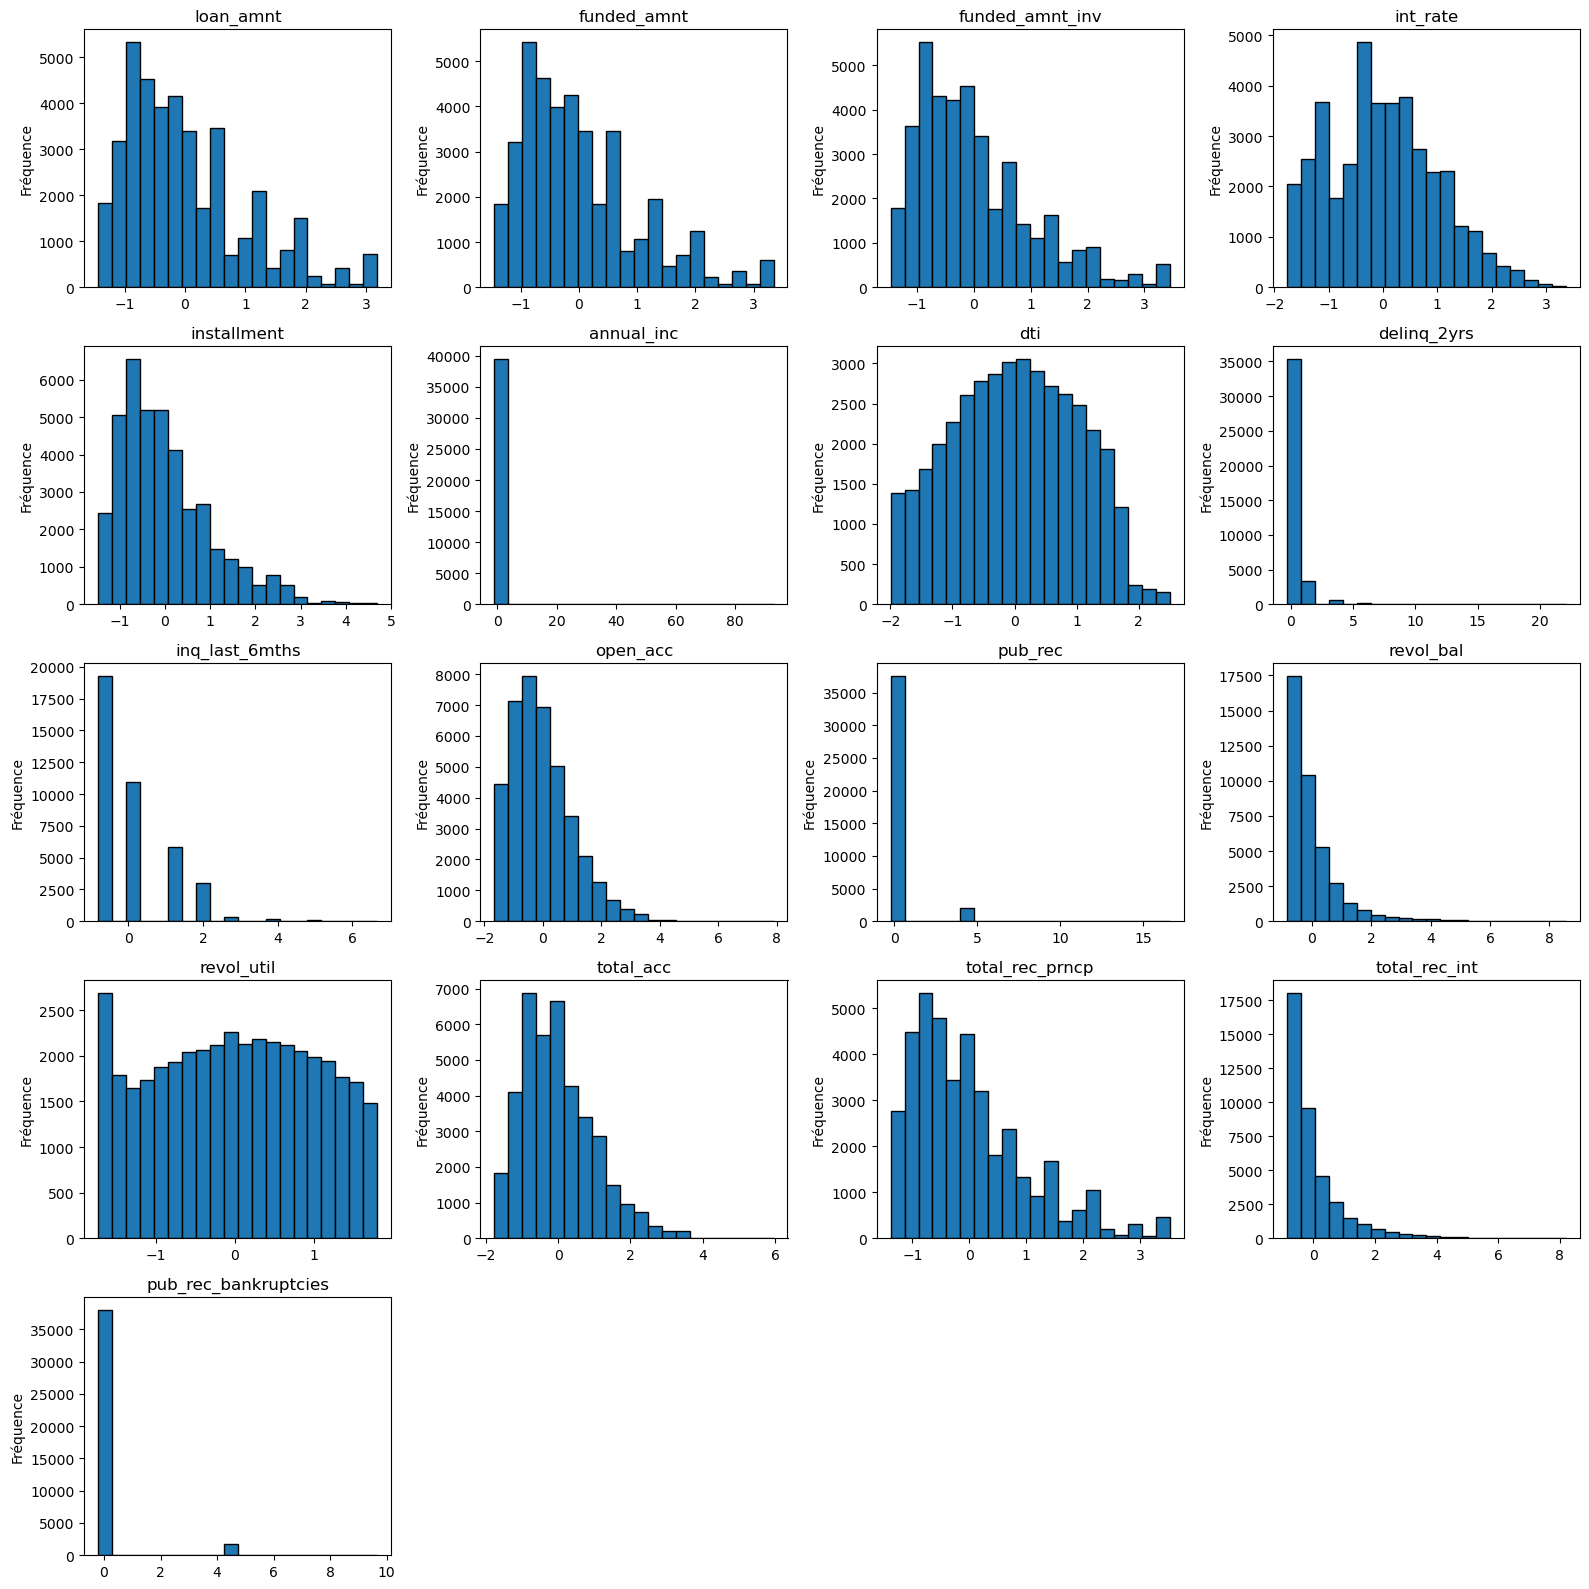

In [55]:
df_data_hist_plot = df_dummies[numeric_cols]
plot_distributions(df_data_hist_plot, bins=20)

## Conclusions